# GSS Cash-Bond Butterfly — Configurable Backtest on QueryDrivenBacktest

A fitted-curve residual on off-the-run USTs: fit a b-spline to the curve, call a bond **cheap** when
it yields more than the fit says it should, build a maturity-weighted butterfly around it, and wait
for the residual to close.

Every choice in that sentence was a decision. Here they are **a dict**, so changing one is an edit
to data rather than to code, and two configurations can be compared without either being privileged.

```python
CONFIG = {
    "construction": {...},   # how the signal and the flies are BUILT   -> costs a 267s scan
    "gate":         {...},   # which candidates are TRADED              -> costs ~8s
    "spline":       "S0_jpm",
}
```

### The split is not cosmetic — it is the whole performance model

    panel (cached)  ->  SCAN candidates  ->  gate  ->  QueryDrivenBacktest prices it

A full run is **251s, of which 247s is `scan_flies`**. The scan depends only on the *construction*
knobs; every gate knob merely filters the same candidate list. So the notebook scans once and then
moves the gates for about a second each — and the gating is still performed by the real
`GSSSignalEngine`, so a swept result cannot drift from a directly-run one. That equivalence is
asserted in §2 rather than assumed.

### What this notebook concludes

The book does not work, and it is worth being precise about *which* claim that is:

| | |
|---|---|
| Signal reproducible? | **Yes** — corr(s2c) 0.983 across a 1.25y knot shift |
| Selection stable? | **No** — the same shift rewrites 95% of the trades |
| Clears its costs? | **No** — m\* ≈ 0.21; costs are 4.5× gross |
| A best configuration? | **No** — DSR 0.177 over 1,164 configs |

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time, json, itertools, warnings
from pathlib import Path

REPO = r"C:\Users\chris\clee\ARBS-rvx"
sys.path.insert(0, REPO)
sys.path.insert(0, str(Path(REPO) / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

plt.style.use("ggplot")
pylab.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": "large",
                       "axes.labelsize": "large"})
pd.set_option("display.width", 180)

from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from BT.gss_fly import GSSConfig, build_curve_panel, resolve_repo_curve
from BT.gss_fly.backtest import run_gss_backtest
from BT.gss_fly.data import ust_business_days
from BT.gss_fly.signals import build_bond_signals
from BT.gss_fly.strategy import GSSSignalEngine, scan_candidates
from BT.gss_fly.conditioning import trade_set_jaccard
from RVUtils.StatisticalFinance.deflated_sharpe import deflated_sharpe_of_best, effective_trials
import gss_grid as G

MDP = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")
CACHE = Path(REPO) / "notebooks" / "data" / "gss_fly" / "panel_cached"

# NOT bdate_range: it contains market holidays, which the source never serves and whose fetcher
# HANGS rather than refusing. One Labor Day stalled two separate panel builds.
DAYS = ust_business_days("2024-09-02", "2026-01-02")
PANEL = build_curve_panel(DAYS, MDP, cache_path=CACHE, show_progress=False)

# `resolve_repo_curve` ANNOUNCES which funding basis you ended up on. The earlier
# `... if REPO_WB.exists() else None` degraded in silence, and when that workbook was deleted every
# number below became gross of funding while still being read as financed. BASIS is stamped into
# every table and figure title in this notebook for exactly that reason.
REPO_WB = Path(r"C:/Users/chris/Downloads/gc_repo_hist_example.xlsx")
REPO_CURVE, BASIS = resolve_repo_curve(REPO_WB, "USTREASGC")

print(PANEL.summary())
print(f"funding basis  : {BASIS}")
print(f"grid           : {len(DAYS)} UST trading days")

REPO: C:\Users\chris\Downloads\gc_repo_hist_example.xlsx does not exist
      UNFINANCED — no repo curve; carry is NOT charged and every P&L below is gross of funding
CurvePanel 332 dates 2024-09-03..2026-01-02, 343 bonds, median RMSE 1.94bp
funding basis  : UNFINANCED
grid           : 332 UST trading days


## 1. The config

One dict fully describes one backtest. The comments name what each knob *does to the book*, taken
from the decision-space measurements in §5 — a knob whose one-step Jaccard is 0.08 is not a tuning
parameter, it is a different strategy.

In [2]:
CONFIG = {
    "name": "incumbent",

    # HOW THE SIGNAL AND FLIES ARE BUILT ----------------------------------
    # Changing any of these costs a fresh 267s scan. They are also the knobs with the most
    # authority over the book: one step moves 55-92% of the trades (see section 5).
    "construction": {
        "signal.ts_weight":             0.75,   # blend of time-series vs cross-sectional z
        "signal.smoothing_halflife":    3.0,
        "signal.scoring_com":           20.0,   # NB the source passes this POSITIONALLY to
                                                # pd.ewma, so it is `com`, not halflife
        "universe.min_ttm":             3.0,
        "fly.wing_range_1":             2.0,    # +/- TTM the wings are drawn from, per bucket
        "fly.wing_range_2":             5.0,
        "fly.std_halflife":            20.0,    # the sigma in ZSig = |z| * sigma_fly
        "fly.fly_smoothing_halflife":   2.0,
        "fly.fly_scoring_com":         30.0,
        "fly.wing_objective":  "signal_gap",    # or "legacy_ttm_bug" — see section 5.1
    },

    # WHICH CANDIDATES ARE TRADED ----------------------------------------
    # Replayed against the cached scan, so each of these costs only its pricing (~8s).
    "gate": {
        "backtest.entry_zsig_bp":       3.0,    # enter when ZSig = |z|*sigma exceeds this
        "costs.repo_penalty_bp":        2.5,    # exit when ZSig decays below this
        "backtest.exit_abs_z":          0.5,
        "backtest.require_turning_point": True, # |z| must already be shrinking: buy the turn
        "backtest.reentry_cooldown_days": 5,
        "backtest.max_concurrent":       10,
        "costs.cost_legs":            "all",    # or "belly_only" — what the GSS source charges
        "costs.scale":                  1.0,    # multiplies the whole half-spread table
    },

    # THE CURVE THE RESIDUAL IS MEASURED AGAINST -------------------------
    # S0_jpm | S1_coarse | S2_dense | S3_shift | S4_with_otr.  A new fit costs a ~19min refit
    # and gets its own cache directory — the day cache is keyed by DATE, so two fits sharing a
    # directory would interleave into a panel that loads, reconciles, and means nothing.
    "spline": "S0_jpm",
}


def build(cfg=CONFIG):
    return G.make_cfg(cfg["construction"], cfg["gate"])


def scan(cfg=CONFIG, panel=None):
    '''The expensive half: candidates per date. Depends ONLY on the construction knobs.'''
    panel = panel if panel is not None else PANEL
    c = build(cfg)
    sig = build_bond_signals(panel.s2c, c.signal)["signal"]
    t0 = time.time()
    cands = scan_candidates(GSSSignalEngine(panel, sig, c, repo_curve=REPO_CURVE), panel.dates)
    return cands, sig, time.time() - t0


def run(cfg=CONFIG, cands=None, panel=None, sig=None):
    '''The cheap half. Pass `cands` from a prior scan when only the gate changed.'''
    panel = panel if panel is not None else PANEL
    return run_gss_backtest(panel, MDP, cfg=build(cfg), repo_curve=REPO_CURVE,
                            show_progress=False, strict=False, candidates=cands)


CANDS, SIG, SCAN_S = scan()
print(f"scan: {sum(len(v) for v in CANDS.values()):,} candidate-days in {SCAN_S:.0f}s")

scan: 56,547 candidate-days in 314s


## 2. Does the machine give the right answer to a question we already know?

A configurable backtest is a measuring instrument, and an instrument that is itself wrong reports
success while hiding the thing it was built to find. Two things are checked before any new number
is read.

**The cached-candidate path must be identical to a live scan.** If it is not, every swept result is
measured on a different book from the one the incumbent was measured on. Asserted on the trade log
*and* the full equity series — not on a summary statistic, because a summary can agree while the
book differs.

**The P&L decomposition must reconcile.** `equity = bond_ledger + financing_ledger − fees +
open_mark`, identically. That assertion refuted two successive and confident explanations of this
book's P&L during development, including one that had already been reported, so it is not
decoration.

In [3]:
res = run(cands=CANDS)
sm  = res.summary()

live = run(cands=None)                     # the slow path, no candidate cache
same_log = res.trade_log[["date", "event", "fly_id"]].reset_index(drop=True).equals(
           live.trade_log[["date", "event", "fly_id"]].reset_index(drop=True))
same_eq  = float(np.nanmax(np.abs(res.equity.dropna().to_numpy()
                                  - live.equity.dropna().to_numpy())))

checks = [
    ("cached scan == live scan (trade log)", same_log, True),
    ("cached scan == live scan (equity, USD)", same_eq < 1e-9, True),
    ("equity holes", res.diagnostics["equity_holes"], 0),
    ("reconciliation gap (USD)", abs(sm["reconciliation_gap_usd"]) < 1e-6, True),
    ("closed >= signal exits", res.diagnostics["closed_positions"] >= res.diagnostics["signal_exits"], True),
]
for name, got, want in checks:
    print(f"  {'PASS' if got == want else 'FAIL'}  {name:42s} {got}")

print(f"\n  entries {res.diagnostics['signal_entries']}   closed {res.diagnostics['closed_positions']}"
      f"   still open {res.diagnostics['still_open']}")
print(f"  end equity  {sm['end_equity_usd']:>14,.0f} USD")

C:\Users\chris\clee\ARBS-rvx\Query\FixedRateBonds\backends\rateslib\RLFixedRateBondPricer.py:5: LicenceNotice: 
Rateslib is source-available (not open-source) software distributed under a dual-licence model.
No commercial licence is registered for this installation. Use is therefore permitted for non-commercial purposes only (at-home or university based academic use).
Any use in commercial, professional, or for-profit environments, including evaluation or trial use, requires a valid commercial licence or an approved evaluation licence.
Certain features may require a registered commercial or evaluation licence in current or future versions.
For licensing information or to register a licence, please visit: https://rateslib.com/licence
  import rateslib as rl


  PASS  cached scan == live scan (trade log)       True
  PASS  cached scan == live scan (equity, USD)     True
  PASS  equity holes                               0
  PASS  reconciliation gap (USD)                   True
  PASS  closed >= signal exits                     True

  entries 35   closed 34   still open 1
  end equity      -4,254,352 USD


## 3. What this config actually trades

The gate is not arbitrary-tight; it sits at the top of the distribution it is cutting into.
`ZSig = |z| · sigma_fly` and the median fly vol is **0.55bp**, so a 3.0bp threshold demands
**|z| > 5.5 sigma**. That number came from the source's EGB book and did not survive the change of
market.

survivors per date
       bonds: mean    343.0   median   342.0   dates>0  332/332
    eligible: mean    186.5   median   187.0   dates>0  332/332
       flies: mean    170.3   median   173.0   dates>0  328/332
   zsig_pass: mean      1.6   median     0.0   dates>0  130/332
   turn_pass: mean      0.7   median     0.0   dates>0   76/332
    zsig_max: median 2.83bp   p90 3.83bp
   sigma_fly: median 0.55bp   -> the 3.0bp gate needs |z| > 5.5


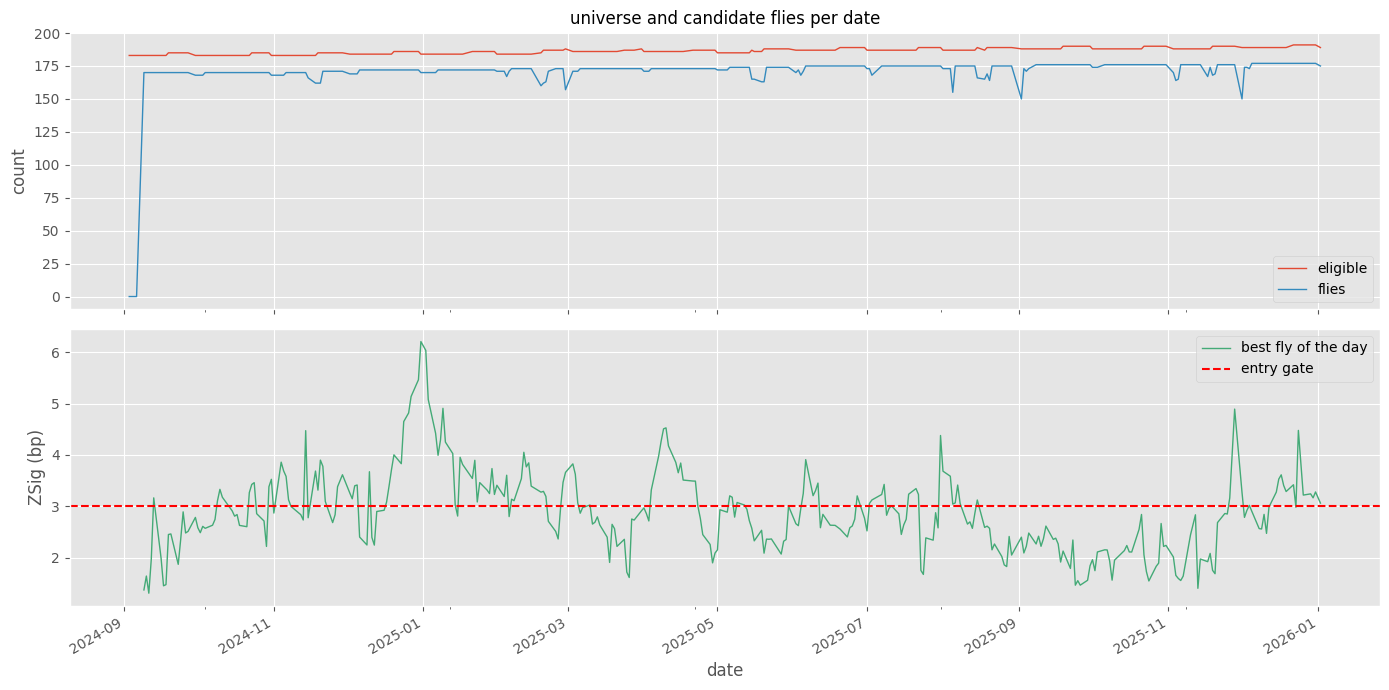

In [4]:
from BT.gss_fly.data import apply_universe_filter

cfg = build()
rows = []
for ts in PANEL.dates:
    curve = PANEL.curve_on(ts)
    if curve.empty:
        continue
    curve = curve.rename(columns={"s2c": "_s2c"})
    curve["signal"] = SIG.loc[ts].reindex(curve.index) if ts in SIG.index else np.nan
    elig = apply_universe_filter(curve, cfg.universe)
    flies = CANDS.get(pd.Timestamp(ts), [])
    zs = np.array([f.zsig_bp for f in flies], float) if flies else np.array([])
    rows.append({
        "date": ts, "bonds": len(curve), "eligible": len(elig), "flies": len(flies),
        "zsig_pass": int((zs > cfg.backtest.entry_zsig_bp).sum()) if zs.size else 0,
        "turn_pass": sum(1 for f in flies if f.zsig_bp > cfg.backtest.entry_zsig_bp
                         and np.isfinite(f.d_abs_z) and f.d_abs_z < 0),
        "zsig_max": float(np.nanmax(zs)) if zs.size else np.nan,
        "std_med": float(np.nanmedian([f.std_bp for f in flies])) if flies else np.nan,
    })
F = pd.DataFrame(rows).set_index("date")

print("survivors per date")
for c in ("bonds", "eligible", "flies", "zsig_pass", "turn_pass"):
    print(f"  {c:>10}: mean {F[c].mean():8.1f}   median {F[c].median():7.1f}"
          f"   dates>0 {int((F[c] > 0).sum()):4d}/{len(F)}")
print(f"  {'zsig_max':>10}: median {F.zsig_max.median():.2f}bp   p90 {F.zsig_max.quantile(.9):.2f}bp")
print(f"  {'sigma_fly':>10}: median {F.std_med.median():.2f}bp"
      f"   -> the {cfg.backtest.entry_zsig_bp}bp gate needs |z| > {cfg.backtest.entry_zsig_bp/F.std_med.median():.1f}")

fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
F[["eligible", "flies"]].plot(ax=ax[0], lw=1).set_ylabel("count")
ax[0].set_title("universe and candidate flies per date")
F["zsig_max"].plot(ax=ax[1], lw=1, color="#4a7", label="best fly of the day")
ax[1].axhline(cfg.backtest.entry_zsig_bp, color="r", ls="--", label="entry gate")
ax[1].set_ylabel("ZSig (bp)"); ax[1].legend(); plt.tight_layout()

## 4. How this config performed

Four **disjoint** terms that sum to the equity curve. The split matters more than the total: the
book pays carry to collect convergence, and hands most of the difference to the bid/offer.

`per_trade_pnl_usd` is deliberately **not** one of the four. It is a different cut of the same
money — already net of fees, already containing the carry realised at unwind — and adding it to the
ledgers double-counted every unwind by $10.7m in an earlier version of this analysis.

incumbent  [UNFINANCED]
  carry during hold        -7,278,913
  unwind proceeds           8,217,382
  fees                     -5,637,475
  open mark                   444,653
  ------------------------------------
  = end equity             -4,254,352   (gap 1.86e-09)

  gross before fees         1,383,123
  cost share of gross          407.6%
  m* (payable share)            0.245   <- >=1 survives its own cost table
  daily Sharpe (ann)            -1.90   +/- 0.87 SE
  max drawdown             -4,812,053
  trades / median hold         34 / 7.5d


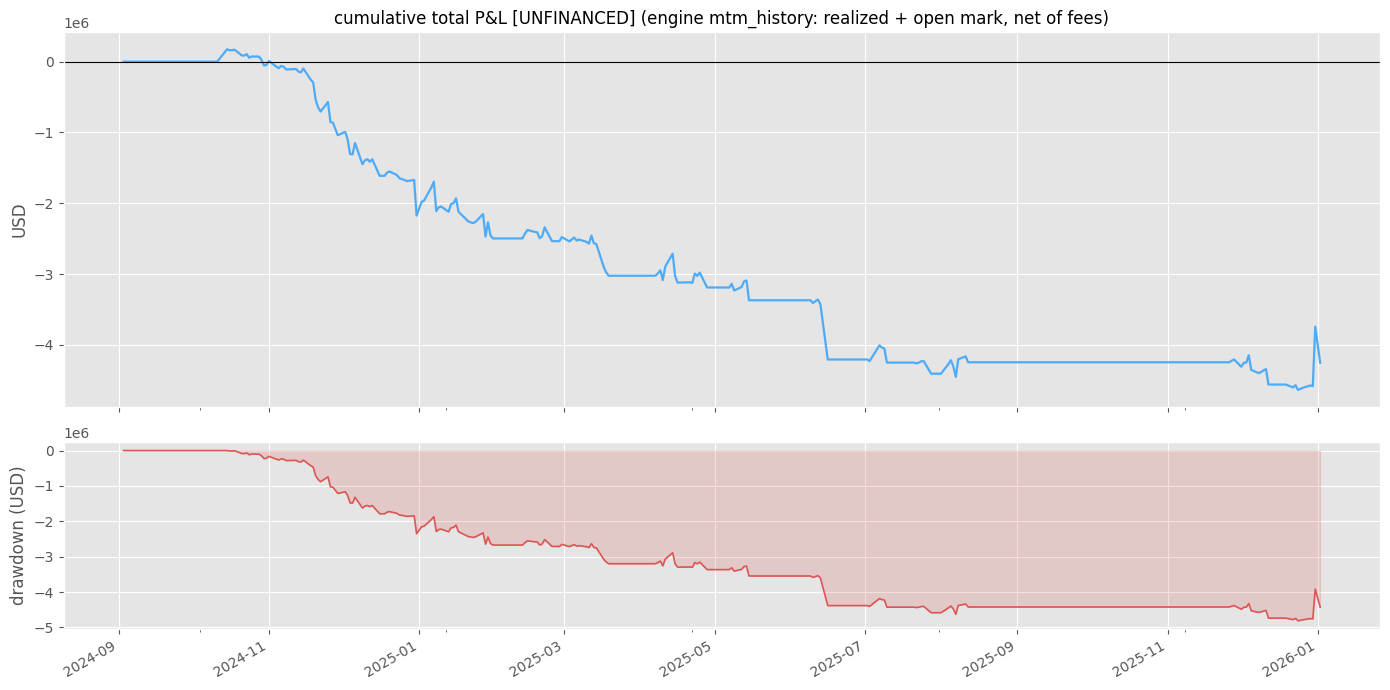

In [5]:
def perf(sm, label=""):
    g, f = sm["gross_before_fees_usd"], -sm["fees_usd"]
    print(f"{label}  [{BASIS}]")
    print(f"  carry during hold   {sm['carry_during_hold_usd']:>15,.0f}")
    print(f"  unwind proceeds     {sm['unwind_proceeds_usd']:>15,.0f}")
    print(f"  fees                {sm['fees_usd']:>15,.0f}")
    print(f"  open mark           {sm['open_mtm_usd']:>15,.0f}")
    print(f"  {'-'*36}")
    print(f"  = end equity        {sm['end_equity_usd']:>15,.0f}   (gap {sm['reconciliation_gap_usd']:.2e})")
    print(f"\n  gross before fees   {g:>15,.0f}")
    print(f"  cost share of gross {f/g if g else np.nan:>15.1%}")
    print(f"  m* (payable share)  {sm.get('breakeven_cost_multiplier', np.nan):>15.3f}"
          f"   <- >=1 survives its own cost table")
    print(f"  daily Sharpe (ann)  {sm['daily_sharpe_ann']:>15.2f}   +/- {np.sqrt(252/sm['marked_days']):.2f} SE")
    print(f"  max drawdown        {sm['max_dd_usd']:>15,.0f}")
    print(f"  trades / median hold {sm['closed_trades']:>10} / {sm['median_hold_days']:.1f}d")

perf(sm, CONFIG["name"])

eq = res.equity.dropna()
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
eq.plot(ax=ax[0], lw=1.6, color="#4dabf7")
ax[0].axhline(0, color="k", lw=0.8); ax[0].set_ylabel("USD")
ax[0].set_title(f"cumulative total P&L [{BASIS}] "
                f"(engine mtm_history: realized + open mark, net of fees)")
(eq - eq.cummax()).plot(ax=ax[1], lw=1.2, color="#d55")
ax[1].fill_between((eq - eq.cummax()).index, (eq - eq.cummax()).to_numpy(), 0,
                   color="#d55", alpha=.2)
ax[1].set_ylabel("drawdown (USD)"); plt.tight_layout()

## 5. The entry / exit level knob — and the boundary the shipped config sits next to

Entry and exit are thresholds on the **same statistic**: enter when `zsig > E`, exit when
`zsig <= X`. Nothing enforces `X < E`. Whenever `E <= X` a fly is entered and *immediately*
qualifies to exit — a full round trip for nothing.

The incumbent is `E = 3.0, X = 2.5`. **Half a basis point from that boundary.**

   E    X  inverted  trades  hold_d          equity  m_star  sharpe
1.00 0.25     False     140   22.00  -21,060,875.67    0.05   -1.81
1.00 1.00      True     351    6.00  -37,961,790.92    0.35   -3.46
1.00 2.50      True    1073    1.00 -165,270,338.07    0.09  -17.88
1.50 0.25     False      96   27.00   -7,195,232.64    0.54   -0.68
1.50 1.00     False     157   12.00   -7,233,890.08    0.71   -0.74
1.50 2.50      True     544    1.00  -72,748,528.58    0.15  -10.42
2.00 0.25     False      63   34.00   -5,497,906.09    0.42   -0.62
2.00 1.00     False      86   16.00   -7,001,826.72    0.46   -0.93
2.00 2.50      True     263    1.00  -31,560,239.34    0.24   -6.39
2.50 0.25     False      35   36.00   -5,372,314.93   -0.01   -0.76
2.50 1.00     False      49   19.00   -7,229,701.11    0.04   -1.22
2.50 2.50      True      89    4.00   -8,854,546.54    0.36   -2.63
3.00 0.25     False      24   35.50   -7,233,716.32   -0.84   -1.36
3.00 1.00     False      25   21.00   -4,150,992

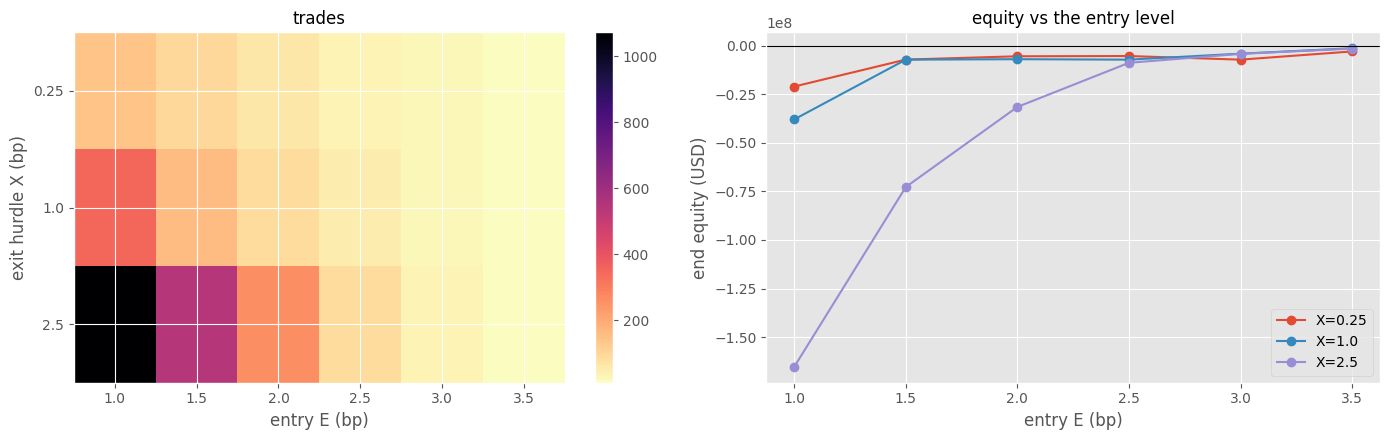

In [6]:
EX = [(e, x) for e in (1.0, 1.5, 2.0, 2.5, 3.0, 3.5) for x in (0.25, 1.0, 2.5)]
rows = []
for e, x in EX:
    c = json.loads(json.dumps(CONFIG))
    c["gate"]["backtest.entry_zsig_bp"], c["gate"]["costs.repo_penalty_bp"] = e, x
    r = run(c, cands=CANDS); s = r.summary()
    rows.append({"E": e, "X": x, "inverted": x >= e, "trades": s["closed_trades"],
                 "hold_d": s["median_hold_days"], "equity": s["end_equity_usd"],
                 "m_star": s.get("breakeven_cost_multiplier", np.nan),
                 "sharpe": s["daily_sharpe_ann"]})
EXT = pd.DataFrame(rows)
print(EXT.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print("\ninverted = X >= E: every entry immediately qualifies to exit.")
# Derive the comparison from whatever levels are present. A configurable notebook whose narrative
# assumes the config still holds its shipped values crashes for the first reader who edits EX —
# which is the entire point of the notebook.
lo = EXT.E.min()
inv = EXT[(EXT.E == lo) & EXT.inverted]
ordered = EXT[(EXT.E == lo) & ~EXT.inverted]
if len(inv) and len(ordered):
    print(f"churn multiple at E={lo}: {inv.trades.max():.0f} trades inverted vs "
          f"{ordered.trades.max():.0f} properly ordered "
          f"({inv.trades.max() / max(ordered.trades.max(), 1):.1f}x)")
else:
    print(f"(no inverted/ordered pair at E={lo} in this sweep — widen EX to see the boundary)")

piv = EXT.pivot(index="X", columns="E", values="trades")
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
im = ax[0].imshow(piv.values, aspect="auto", cmap="magma_r")
ax[0].set_xticks(range(len(piv.columns)), piv.columns); ax[0].set_yticks(range(len(piv.index)), piv.index)
ax[0].set_xlabel("entry E (bp)"); ax[0].set_ylabel("exit hurdle X (bp)"); ax[0].set_title("trades")
plt.colorbar(im, ax=ax[0])
for x_, gdf in EXT.groupby("X"):
    ax[1].plot(gdf.E, gdf.equity, marker="o", label=f"X={x_}")
ax[1].axhline(0, color="k", lw=.8); ax[1].set_xlabel("entry E (bp)"); ax[1].set_ylabel("end equity (USD)")
ax[1].legend(); ax[1].set_title("equity vs the entry level"); plt.tight_layout()

## 6. The construction knobs — measured where there is no estimation error

Performance cannot rank these. On 331 daily marks `SE(annualised Sharpe) = sqrt(252/331) = 0.87`,
and a *difference* between two configs needs roughly **2.4** before it means anything. The completed
3,432-row sweep spans p05–p95 of **3.29** — wider than two standard errors, unlike an early
36-config draft — but a ranking over 3,415 configs separated by less than 2.4 is still noise wearing
a leaderboard, which is what the deflated Sharpe in §8 is for.

**Which trades a config takes is deterministic**, so that is where conditioning is measurable.
Jaccard against the incumbent, one step per knob: `J ~ 0.9` is a nuisance knob, `J ~ 0.5` means the
knob redefines the book, `J <= 0.2` means a different strategy entirely.

Each step costs a fresh ~325s scan and there are 25 of them, so this is **not** computed here — it
is read from what `scripts/gss_decision_conditioning.py` already produced. A notebook cell that
quietly spends two and a half hours is one you stop trusting to run; this one says what to run
instead when the artifact is missing.

                                             steps  min_J  median_J  median_tol  trades_lo  trades_hi  timing_gap
group        knob                                                                                                
gate         backtest.require_turning_point      1  0.084     0.084       0.139         55         55       0.055
             backtest.entry_zsig_bp              5  0.023     0.090       0.098         13       1080       0.008
construction signal.ts_weight                    3  0.043     0.097       0.129         13         44       0.031
             signal.smoothing_halflife           2  0.066     0.139       0.158         30         39       0.019
             fly.fly_scoring_com                 3  0.023     0.167       0.167         10         51       0.000
             signal.scoring_com                  2  0.161     0.169       0.179         30         38       0.010
             fly.fly_smoothing_halflife          2  0.232     0.236       0.236         

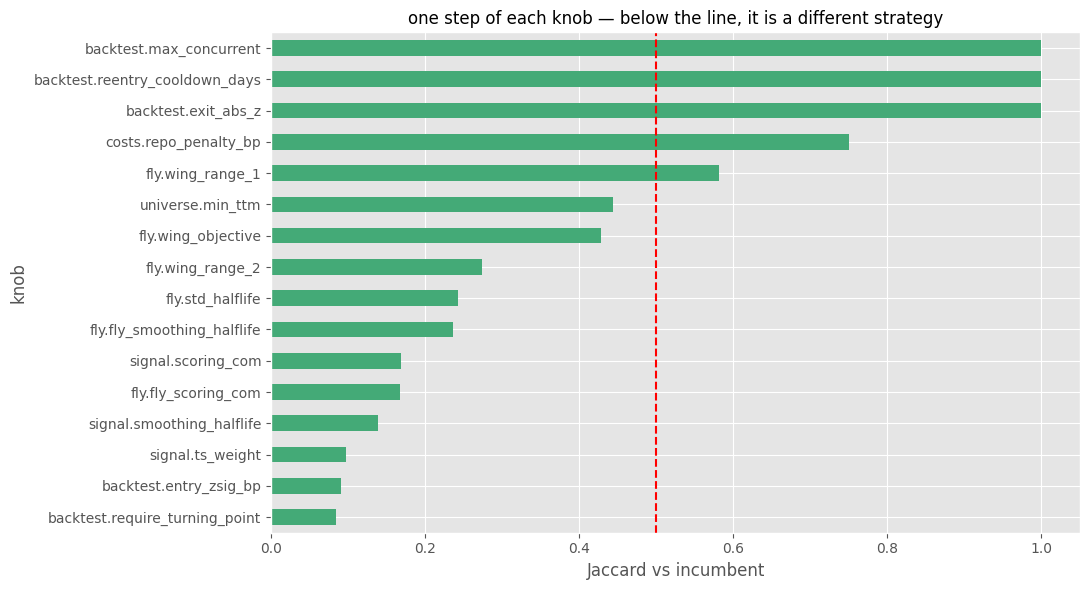

In [7]:
COND = Path(REPO) / "notebooks" / "data" / "gss_fly" / "decision_conditioning.csv"
if not COND.exists():
    print(f"{COND} not built — run:\n"
          f"    conda run -n stir python scripts/gss_decision_conditioning.py\n"
          f"(~25 scans, about 2.5h. Deliberately NOT done inline.)")
else:
    CJ = pd.read_csv(COND)
    CJ["group"] = np.where(CJ["knob"].str.startswith(("backtest.", "costs.")), "gate", "construction")
    prof = (CJ.groupby(["group", "knob"])
              .agg(steps=("setting", "count"), min_J=("jaccard_exact", "min"),
                   median_J=("jaccard_exact", "median"), median_tol=("jaccard_tol", "median"),
                   trades_lo=("n_enter", "min"), trades_hi=("n_enter", "max"))
              .assign(timing_gap=lambda d: d.median_tol - d.median_J)
              .sort_values("median_J"))
    print(prof.to_string(float_format=lambda v: f"{v:.3f}"))
    print("\ntiming_gap ~ 0 means the knob changes WHICH trades, not WHEN — not jitter around a"
          " stable book.")
    print("NB entry_zsig_bp's 13 -> 1,080 trade span is an E/X INTERACTION, not the knob's own"
          "\nsensitivity: entry and exit threshold the same statistic, so sweeping E below X=2.5"
          "\nenters flies that immediately qualify to exit. Properly ordered at E=1.0/X=0.25 the"
          "\nbook takes 150. The shipped config sits 0.5bp from that boundary.")
    ax = prof.reset_index().set_index("knob")["median_J"].plot(
        kind="barh", figsize=(11, 6), color="#4a7")
    ax.axvline(0.5, color="r", ls="--"); ax.set_xlabel("Jaccard vs incumbent")
    ax.set_title("one step of each knob — below the line, it is a different strategy")
    plt.tight_layout()

## 7. Costs — the binding constraint

`m* = gross / fees` is the fraction of the charged bid/offer the book can actually pay. `m* >= 1`
survives; the incumbent is **0.245**, i.e. execution would have to be about **4× tighter**.

The fee never feeds back into the trade decision, so the whole cost axis is recoverable in closed
form from one run — no re-pricing needed.

  cost_legs=all         fees    -5,637,475  equity    -4,254,352  m* 0.245


  cost_legs=belly_only  fees    -2,740,000  equity    -1,356,877  m* 0.505


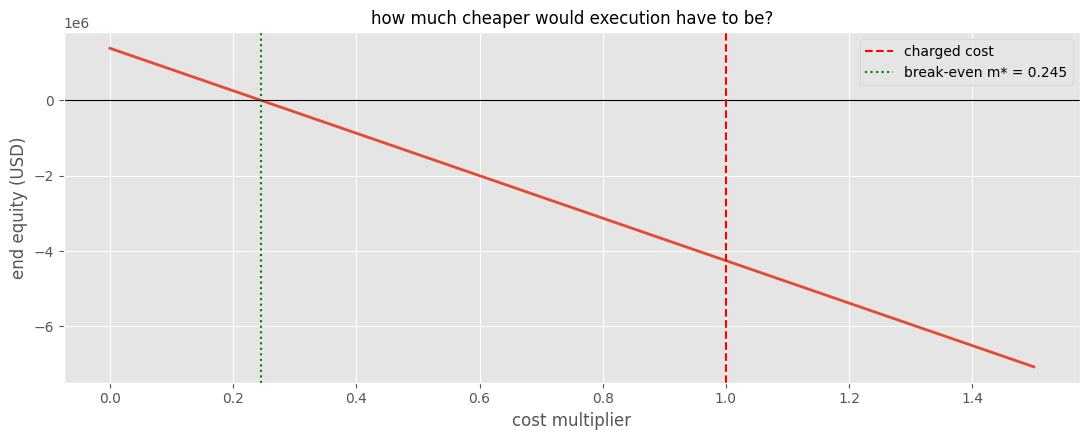

In [8]:
from BT.gss_fly.conditioning import breakeven_cost_multiplier, equity_at_cost_multiplier

for legs in ("all", "belly_only"):
    c = json.loads(json.dumps(CONFIG)); c["gate"]["costs.cost_legs"] = legs
    r = run(c, cands=CANDS); s = r.summary()
    print(f"  cost_legs={legs:11s} fees {s['fees_usd']:>13,.0f}  equity {s['end_equity_usd']:>13,.0f}"
          f"  m* {s.get('breakeven_cost_multiplier', np.nan):.3f}")

ms = np.linspace(0, 1.5, 31)
ends = [equity_at_cost_multiplier(res.equity, res.closed, m).iloc[-1] for m in ms]
mstar = breakeven_cost_multiplier(res.equity, res.closed)
plt.figure(figsize=(11, 4.5))
plt.plot(ms, ends, lw=2); plt.axhline(0, color="k", lw=.8)
plt.axvline(1.0, color="r", ls="--", label="charged cost")
plt.axvline(mstar, color="g", ls=":", label=f"break-even m* = {mstar:.3f}")
plt.xlabel("cost multiplier"); plt.ylabel("end equity (USD)")
plt.title("how much cheaper would execution have to be?"); plt.legend(); plt.tight_layout()

## 8. The spline knob — signal or selection?

The residual is measured against a fitted curve, so the obvious worry is that the fit manufactures
it. `S3_shift` tests exactly that: the **same number of knots, slid 1.25 years**. Nothing about the
market changes, only where the spline may bend.

**A trade-set Jaccard cannot answer this question**, and reading one as if it could is a mistake
this analysis actually made. Jaccard came back 0.045 and the first conclusion drawn was "the signal
reads the interpolator". The discriminating quantity is the s2c **values**:

| | S0 vs S3 |
|---|---|
| corr(s2c) | **0.983** |
| Spearman rank | **0.944** |
| trade Jaccard | **0.045** |

The signal barely moves and the book is rewritten anyway, because selection is a hard top-N over
~173 near-tied candidates a day and 0.26bp — a seventh of a standard deviation — reorders the top
of the list. **The selection is chaotic; the signal is not.** That is a fixable design fault
(rank-average across fits, require a gap to the next-best candidate, size by conviction) rather than
a dead idea — though it does not rescue the economics in §7.

Requires the alternate panel; skipped cleanly if it has not been built.

In [9]:
alt = "S3_shift"
try:
    P_ALT = build_curve_panel(DAYS, MDP, cache_path=CACHE, show_progress=False,
                              spline_config=G.spline_variants()[alt])
except Exception as exc:
    P_ALT = None
    print(f"{alt} panel not built ({type(exc).__name__}); "
          f"run scripts/gss_spline_panels.py --spline {alt}")

if P_ALT is not None:
    A, B = PANEL.s2c, P_ALT.s2c
    cols, idx = A.columns.intersection(B.columns), A.index.intersection(B.index)
    cs, rk = [], []
    for t in idx:
        x, y = A.loc[t, cols], B.loc[t, cols]
        m = x.notna() & y.notna()
        if m.sum() > 10:
            cs.append(np.corrcoef(x[m], y[m])[0, 1])
            rk.append(x[m].rank().corr(y[m].rank(), method="spearman"))
    cd_alt, sig_alt, _ = scan(CONFIG, panel=P_ALT)
    r_alt = run(CONFIG, cands=cd_alt, panel=P_ALT)
    print(f"  corr(s2c)        median {np.median(cs):.4f}   p05 {np.percentile(cs,5):.4f}")
    print(f"  Spearman rank    median {np.median(rk):.4f}")
    print(f"  trade Jaccard    {trade_set_jaccard(res.trade_log, r_alt.trade_log):.4f}")
    print(f"  entries          {res.diagnostics['signal_entries']} -> {r_alt.diagnostics['signal_entries']}")
    print("\n  A high correlation with a low Jaccard means the SELECTION is chaotic, not the signal.")

  corr(s2c)        median 0.9826   p05 0.9546
  Spearman rank    median 0.9444
  trade Jaccard    0.0455
  entries          35 -> 34

  A high correlation with a low Jaccard means the SELECTION is chaotic, not the signal.


## 9. What the search cost

Every knob turned above is a trial, and the maximum of many noisy estimates is large even when
nothing has an edge. The Deflated Sharpe asks the only useful question: **is this Sharpe bigger than
the best one this search would have produced by chance?**

Over the full 1,164-config sweep (`scripts/gss_grid.py`) the answer is no — the best config lands
**below** the bar its own search sets. The bar is high because a Sharpe on 331 daily marks has a
standard error of 0.87, not because the test is harsh: cross-config sd is 0.884 against a per-config
SE of 0.873, a ratio of 1.013, so the entire spread across the parameter space *is* estimation noise.

  configs                 3,432
  effective ind. trials   2878 (84%)
  best Sharpe             +2.86 ann
  SR0 (the bar)           +3.53 ann
  DSR                     0.188     (needs > 0.95)

  cross-config sd 0.997 vs per-config SE 0.873  -> ratio 1.143  (1.0 = the spread IS the noise)


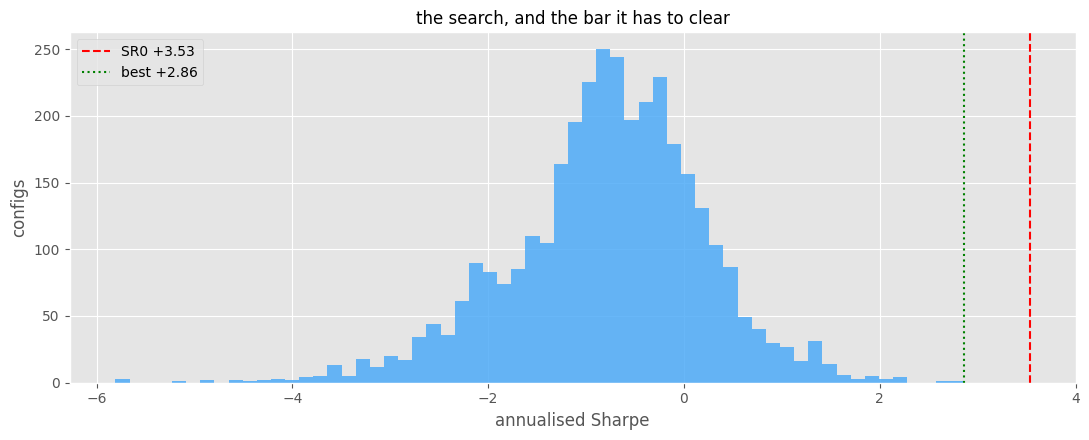

In [10]:
GRID = Path(REPO) / "notebooks" / "data" / "gss_fly" / "grid" / "S0_jpm" / "rows"
files = sorted(GRID.glob("*.parquet"))
if not files:
    print("no sweep on disk; run scripts/gss_grid.py --workers 20")
else:
    sweep = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    sweep = sweep[sweep.get("ok", False) == True]                                  # noqa: E712
    series = [np.asarray(json.loads(s), float) for s in sweep["daily_pnl"]]
    series = [s for s in series if len(s) > 20 and np.isfinite(s).all() and s.std() > 0]
    out = deflated_sharpe_of_best(series)
    ann = np.sqrt(252)
    print(f"  configs                 {len(series):,}")
    print(f"  effective ind. trials   {out['n_trials_effective']:.0f} "
          f"({out['n_trials_effective']/len(series):.0%})")
    print(f"  best Sharpe             {out['best_sharpe']*ann:+.2f} ann")
    print(f"  SR0 (the bar)           {out['sr0']*ann:+.2f} ann")
    print(f"  DSR                     {out['dsr']:.3f}     (needs > 0.95)")
    s_ann = sweep["sharpe_ann"].replace([np.inf, -np.inf], np.nan).dropna()
    se = np.sqrt(252 / sweep["n_obs"].median())
    print(f"\n  cross-config sd {s_ann.std():.3f} vs per-config SE {se:.3f}"
          f"  -> ratio {s_ann.std()/se:.3f}  (1.0 = the spread IS the noise)")
    plt.figure(figsize=(11, 4.5))
    plt.hist(s_ann, bins=60, color="#4dabf7", alpha=.85)
    plt.axvline(out["sr0"]*ann, color="r", ls="--", label=f"SR0 {out['sr0']*ann:+.2f}")
    plt.axvline(s_ann.max(), color="g", ls=":", label=f"best {s_ann.max():+.2f}")
    plt.xlabel("annualised Sharpe"); plt.ylabel("configs")
    plt.title("the search, and the bar it has to clear"); plt.legend(); plt.tight_layout()

## 10. Trade log

In [11]:
if not res.closed.empty:
    cols = [c for c in ("opened_at", "closed_at", "holding_period_days", "realized_pnl",
                        "gross_realized_pnl", "fee_allocated") if c in res.closed.columns]
    T = res.closed[cols].copy()
    T["fly"] = [ (m or {}).get("fly_id") for m in res.closed.get("position_meta", [{}]*len(res.closed)) ]
    print(T.to_string(index=False, float_format=lambda v: f"{v:,.0f}"))
    print(f"\nNOTE realized_pnl is the PER-TRADE cut: already net of fees and already containing "
          f"the carry realised at unwind.\nIt sums to {res.closed['realized_pnl'].sum():,.0f} "
          f"against a book that made {sm['end_equity_usd']:,.0f}. They are different questions.")

 opened_at  closed_at  holding_period_days  realized_pnl  gross_realized_pnl  fee_allocated                           fly
2024-10-11 2024-10-15                    4       178,076             278,254        100,178 912810FG8-91282CKD2-91282CBL4
2024-10-11 2024-11-18                   38       437,947             652,195        214,248 912810QE1-912810SY5-912810RM2
2024-10-31 2024-11-20                   20    -1,608,243          -1,388,264        219,979 912810QD3-912810TA6-912810RK6
2024-11-20 2024-11-26                    6      -230,477             -30,477        200,000 912810FT0-912810QD3-912810TS7
2024-11-21 2024-11-29                    8      -188,431              38,238        226,669 912810PW2-912810TF5-912810RV2
2024-12-02 2024-12-05                    3       -89,183              10,817        100,000 91282CBB6-912810FF0-91282CFT3
2024-12-03 2024-12-09                    6      -195,291               4,709        200,000 912810PW2-912810TK4-912810RJ9
2024-11-18 2024-12-16   

## 11. Reading this notebook

**Do not rank configurations by Sharpe.** With 331 daily marks the standard error is 0.87
annualised and the entire cross-config spread is 0.88. Any "best config" chosen here is a draw from
noise, and §9 shows the best of 1,164 lands below the bar the search itself sets.

**The knobs are not tuning parameters.** Twelve of sixteen change more than half the trade set in
one step; the worst is a boolean. "The GSS strategy" is one arbitrary point whose neighbours are
different strategies sharing a name — so a performance figure quoted for it describes that point,
not the idea.

**Three claims this analysis got wrong and corrected**, kept here because each was reported before
it was checked:

1. *"Cost-dead everywhere"* — too absolute. 13% of the space does cover its charged spread; those
   configs are what the DSR then rejects.
2. *"The signal reads the interpolator"* — wrong. corr(s2c) = 0.983; it was the argmax cascading.
   A trade-set Jaccard cannot distinguish the two, and §8 measures the quantity that can.
3. *"31× swing from `entry_zsig_bp`"* — misattributed. It is an `E`/`X` interaction, and the real
   finding is that the shipped config sits 0.5bp from a churn boundary.

**What holds.** The signal is reproducible. The selection built on it is not. The book pays about
$7.9m of carry to collect $10.7m of convergence and hands $5.6m to the bid/offer, so m\* ≈ 0.21 —
and no configuration in the sampled space is defensible.